In [32]:
from pathlib import Path
import pandas as pd
DATA_PATH = Path("/home/gkulemeyer/Documents/Repos/RNADiffusion/data")

In [33]:
df_ref = pd.read_csv(DATA_PATH / "ArchiveII.csv", index_col="id")
df_ref.head(2)

,sequence,structure,base_pairs,len
id,,,,
5s_Acholeplasma-laidlawii-1,UCUGGUGACGAUAGGUAAGAUGGUUCACCUGUUCCCAUCCCGAACA...,((((((((......((((((((....((((((.............)...,"[[1, 111], [2, 110], [3, 109], [4, 108], [5, 1...",112
5s_Acidovorax-temperans-1,UGCCUGAUGACCAUAGCAAGUUGGUACCACUCCUUCCCAUCCCGAA...,.(((((((((.....((((((((.....((((((...............,"[[2, 115], [3, 114], [4, 113], [5, 112], [6, 1...",115


In [34]:
sim_folds_6 = DATA_PATH / "simfolds/6_sim_folds/"
files = [file for file in sim_folds_6.iterdir() if file.is_file() and file.suffix == ".csv"]
files.sort()
print(files)

sim_df = {file.name.split("-")[0].split("_")[-1] : pd.read_csv(file, index_col="id") for file in files}
for sim, df_s in sim_df.items():
    df_s.drop(columns=["fold_name"], inplace=True)
sim_df.keys()

[PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim50-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim60-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim70-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/6_sim_folds/archiveII_similars_splits_less_than_512_k10_NOboostrap_sim80-fold.csv'), PosixPath('/home/gkulemeyer/Documents/Repos/RNADiffusion/data/s

dict_keys(['sim30', 'sim40', 'sim50', 'sim60', 'sim70', 'sim80', 'sim90'])

In [35]:
for sim, df_s in sim_df.items():
    sim_df[sim] = pd.merge(df_ref, df_s, left_index=True, right_index=True, how="inner")
    print(f"sim: {sim}")
    display(df_s)

sim: sim30


,fold_number,partition
id,,
16s_C.reinhardtii.mito_domain3,0,train
srp_Kluy.lact._CR382126,0,train
grp1_a.I1.e.L.dispersa.UNK.SSU.1210,0,train
grp1_a.I1.e.L.dispersa.UNK.SSU.789,0,valid
16s_M.polymorpha_domain3,0,test
16s_C.reinhardtii.mito_domain3,1,train
16s_M.polymorpha_domain3,1,train
grp1_a.I1.e.L.dispersa.UNK.SSU.1210,1,train
srp_Kluy.lact._CR382126,1,valid


sim: sim40


,fold_number,partition
id,,
telomerase_AF221919.107-614,0,train
grp1_a.I1.b.Phormidium.sp.N182.C3.tLEU,0,train
16s_H.sapiens.mito_domain3,0,train
telomerase_AF221913.109-520,0,train
16s_M.polymorpha_domain3,0,train
...,...,...
grp1_a.I1.b.Synechococcus.sp2.C3.tLEU,9,test
grp1_a.I1.c.G.prostrata.C3.tLEU,9,test
RNaseP_M.barkeri,9,test


sim: sim50


...

,fold_number,partition
id,,
16s_G.intestinalis_domain3,0,train
srp_Neph.oliv._AF137379,0,train
RNaseP_A.laidlawii,0,train
RNaseP_P.hollandica,0,train
tmRNA_Myco.Bxz1._AY129337_1-437,0,train
...,...,...
5s_Mycoplasma-penetrans-1,9,test
RNaseP_SM-A2135,9,test
tmRNA_envi.sequ._TRW-32045-3_1-350,9,test


sim: sim80


,fold_number,partition
id,,
RNaseP_Synechococcus-PCC7001,0,train
RNaseP_B.stearothermophilus,0,train
RNaseP_EM14b-9,0,train
16s_P.staleyi_domain4,0,train
srp_Giar.lamb._GSP-184922,0,train
...,...,...
srp_Tric.eryt._CP000393,9,test
RNaseP_Calothrix-PCC7601,9,test
RNaseP_X.fastidiosa,9,test


sim: sim90


,fold_number,partition
id,,
tRNA_tdbR00000170-Saccharomyces_cerevisiae-4932-Ile-IAU,0,train
5s_Gemm_obscuB,0,train
RNaseP_S.mutans,0,train
5s_Roseococcus-thiosulfatophilus-2,0,train
srp_Proc.mari._BX572093,0,train
...,...,...
5s_Neurospora-crassa-11,9,test
RNaseP_S.servazzii,9,test
telomerase_AF221918.97-547,9,test


In [45]:
for sim, df_s in sim_df.items():  
    print(    df_s.groupby("partition").value_counts()#.unstack("partition").plot(kind="barh", grid=True, title=sim)
)

partition  sequence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             structure                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

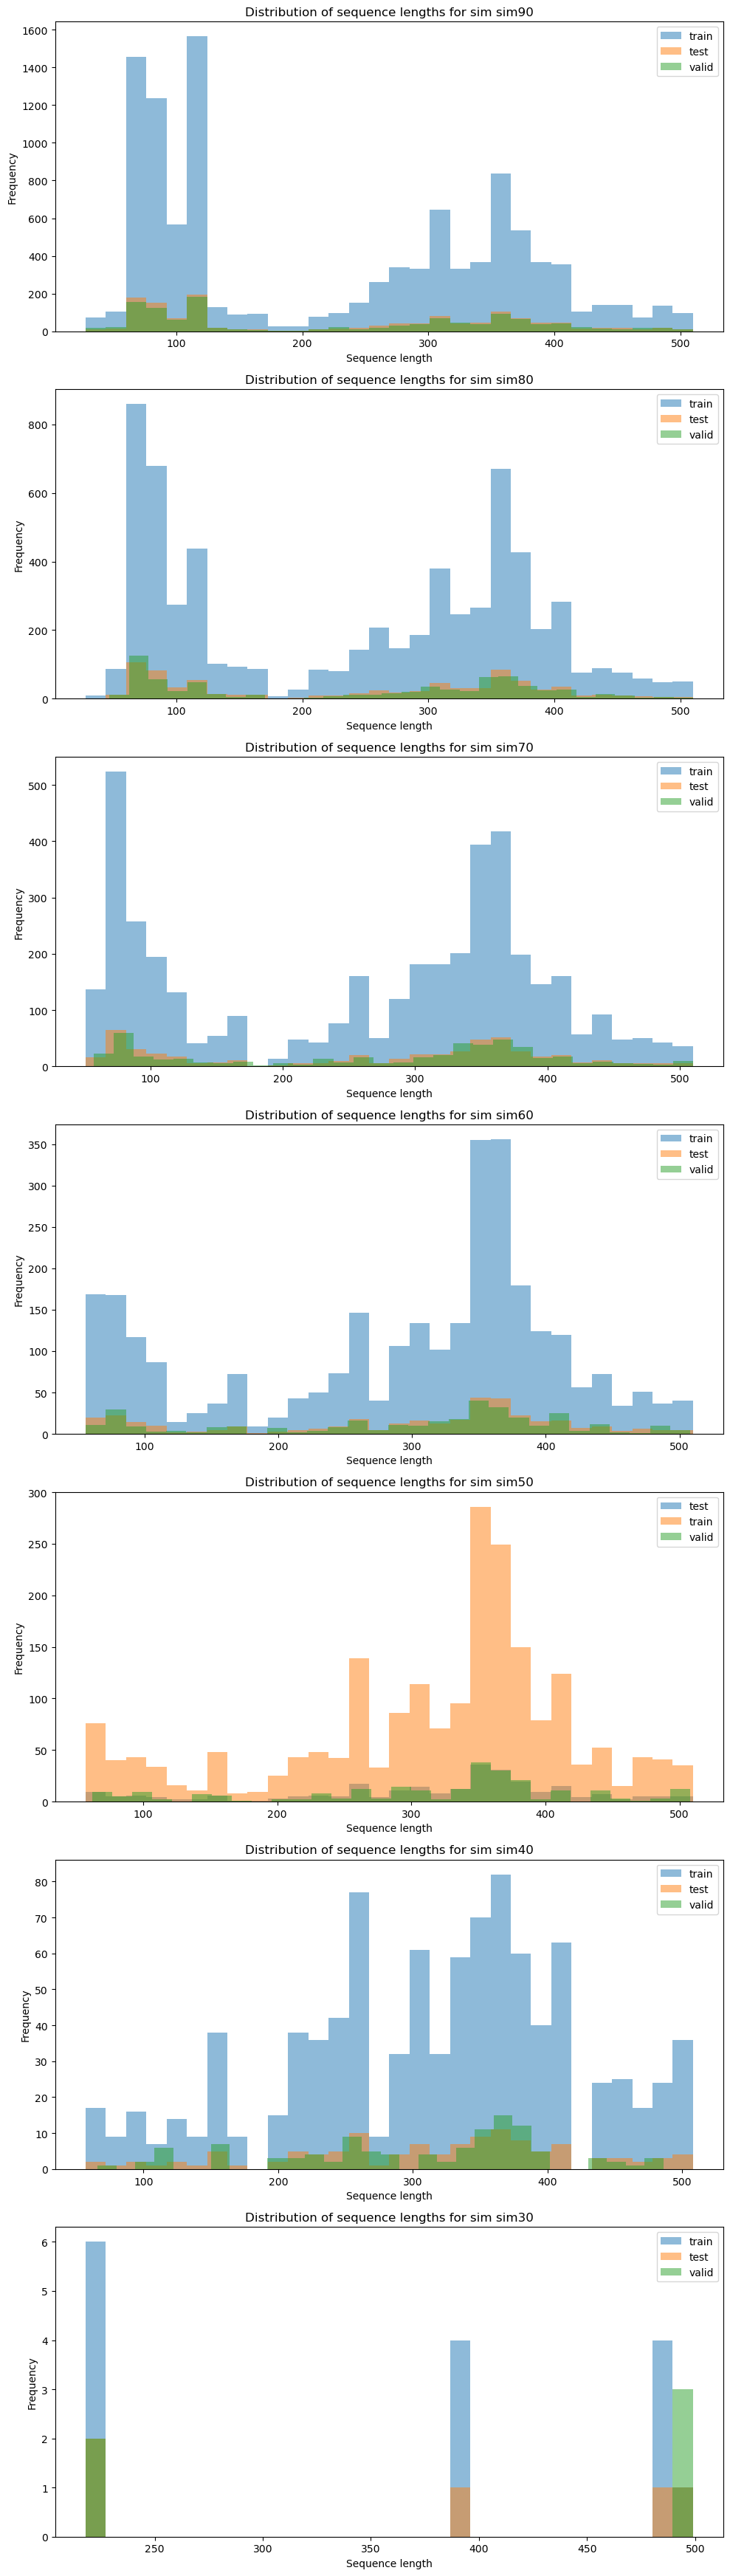

In [39]:
import matplotlib.pyplot as plt

# plot distribution of sequence lengths for each sim and partition
# sims = ["sim50", "sim60", ... ]
n_sims = len(sim_df)
fig, axes = plt.subplots(n_sims, 1, figsize=(10, 5 * n_sims))
for sim, df_s in sim_df.items(): 
    ax = axes[n_sims - 1 - list(sim_df.keys()).index(sim)] 
    for partition in df_s["partition"].unique():
        df_p = df_s[df_s["partition"] == partition].sort_values("partition")
        ax.hist(df_p["len"], bins=30, alpha=0.5, label=partition)
    ax.set_title(f"Distribution of sequence lengths for sim {sim}")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.show()

In [5]:
 

valid_ids = (
    df_ref
    .loc[df_ref["len"] <= 512, "id"]
    .unique()
)

df_filt = {}
for sim, df_s in sim_df.items(): 
    df_filt[sim] = df_s[df_s["id"].isin(valid_ids)].reset_index(drop=True) 

In [6]:
df_filt = {}
for sim, df_s in sim_df.items():
    print(10 * "-" + f"sim: {sim}" + 10 * "-" )
    df_filt[sim] = df_s[df_s["id"].isin(valid_ids)].reset_index(drop=True)
    print("Full")
    print(df_s.query("fold_number == 0")["partition"].value_counts())
    print("max128")
    print(df_filt[sim].query("fold_number == 0")["partition"].value_counts())

----------sim: sim30----------
Full
partition
train    3
valid    1
test     1
Name: count, dtype: int64
max128
partition
train    3
valid    1
test     1
Name: count, dtype: int64
----------sim: sim40----------
Full
partition
train    96
test     12
valid    11
Name: count, dtype: int64
max128
partition
train    96
test     12
valid    11
Name: count, dtype: int64
----------sim: sim50----------
Full
partition
train    209
test      26
valid     24
Name: count, dtype: int64
max128
partition
train    209
test      26
valid     24
Name: count, dtype: int64
----------sim: sim60----------
Full
partition
train    297
test      37
valid     33
Name: count, dtype: int64
max128
partition
train    297
test      37
valid     33
Name: count, dtype: int64
----------sim: sim70----------
Full
partition
train    414
test      52
valid     47
Name: count, dtype: int64
max128
partition
train    414
test      52
valid     47
Name: count, dtype: int64
----------sim: sim80----------
Full
partition
train  

In [7]:
import pandas as pd

rows = []

df_filt = {}

for sim, df_s in sim_df.items():
    df_filt[sim] = df_s[df_s["id"].isin(valid_ids)].reset_index(drop=True)

    # Conteos FULL
    full_counts = (
        df_s.query("fold_number == 0")["partition"]
        .value_counts()
        .to_dict()
    )

    # Conteos FILTRADO (max128)
    filt_counts = (
        df_filt[sim].query("fold_number == 0")["partition"]
        .value_counts()
        .to_dict()
    )

    # Guardamos en formato largo
    for part, n in full_counts.items():
        rows.append({
            "sim": sim,
            "dataset": "full",
            "partition": part,
            "count": n
        })

    for part, n in filt_counts.items():
        rows.append({
            "sim": sim,
            "dataset": "max512",
            "partition": part,
            "count": n
        })

# DataFrame final
counts_df = pd.DataFrame(rows)

In [8]:
# valid_ids = (
#     df_seq
#     .loc[df_seq["len"] <= 128, "id"]
#     .unique()
# )
# df_part_filt = df_part[df_part["id"].isin(valid_ids)].reset_index(drop=True)
# print("Antes:", len(df_part))
# print("Después:", len(df_part_filt))

# assert df_part_filt["id"].isin(valid_ids).all()


<Axes: ylabel='sim'>

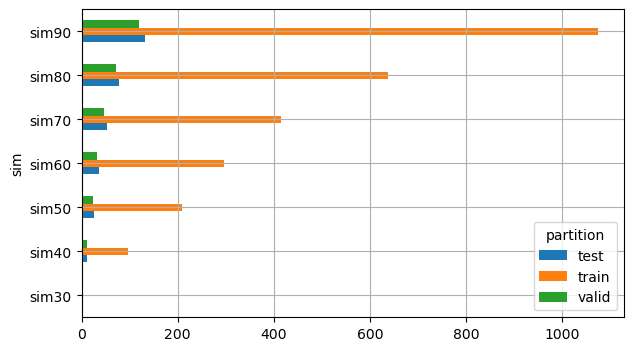

In [10]:
#counts_df.query("dataset == 'max128'").groupby(["sim"])["count"].sum().plot(kind="barh",hue="partition", grid=True)
(
    counts_df
    .query("dataset == 'max512'")
    .groupby(["sim", "partition"])["count"]
    .sum()
    .unstack("partition")
    .plot(
        kind="barh",
        figsize=(7, 4),
        grid=True
    )
)


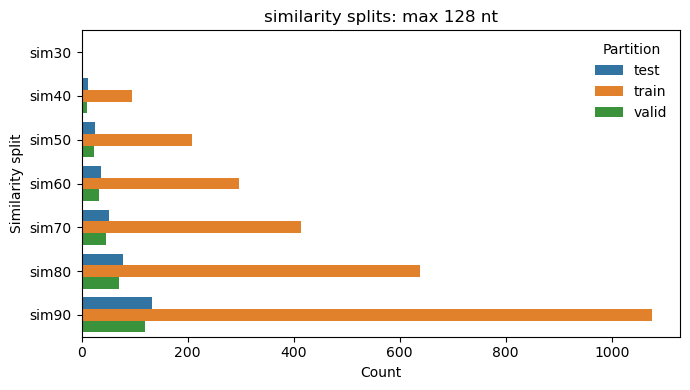

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
df_plot = (
    counts_df
    .query("dataset == 'max512'")
    .groupby(["sim", "partition"], as_index=False)["count"]
    .sum()
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=df_plot,
    y="sim",
    x="count",
    hue="partition",
    orient="h"
)

ax.set_xlabel("Count")
ax.set_ylabel("Similarity split")
ax.legend(title="Partition", frameon=False)
plt.title("similarity splits: max 128 nt")
plt.tight_layout()
plt.show()


/tmp/ipykernel_364192/3385826384.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=counts_df, x="sim", y="count", hue="dataset", ci=None)


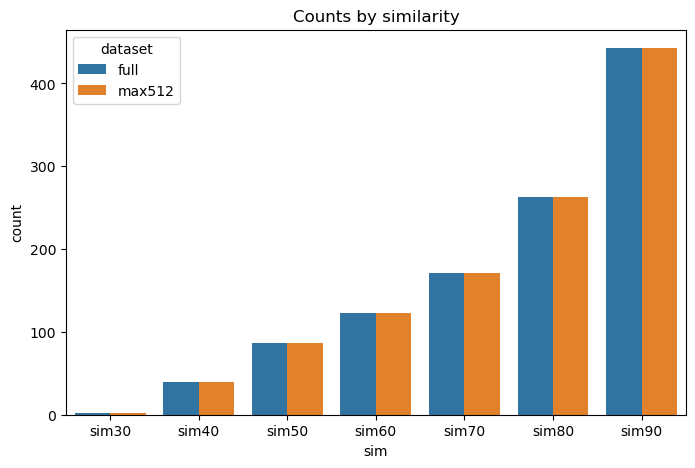

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=counts_df, x="sim", y="count", hue="dataset", ci=None)
plt.title("Counts by similarity")
plt.show()

# plt.figure(figsize=(8,5))
# sns.barplot(data=counts_df, x="partition", y="count", hue="dataset", ci=None, kind="stack")
# plt.title("Partitions distribution")
# plt.show()

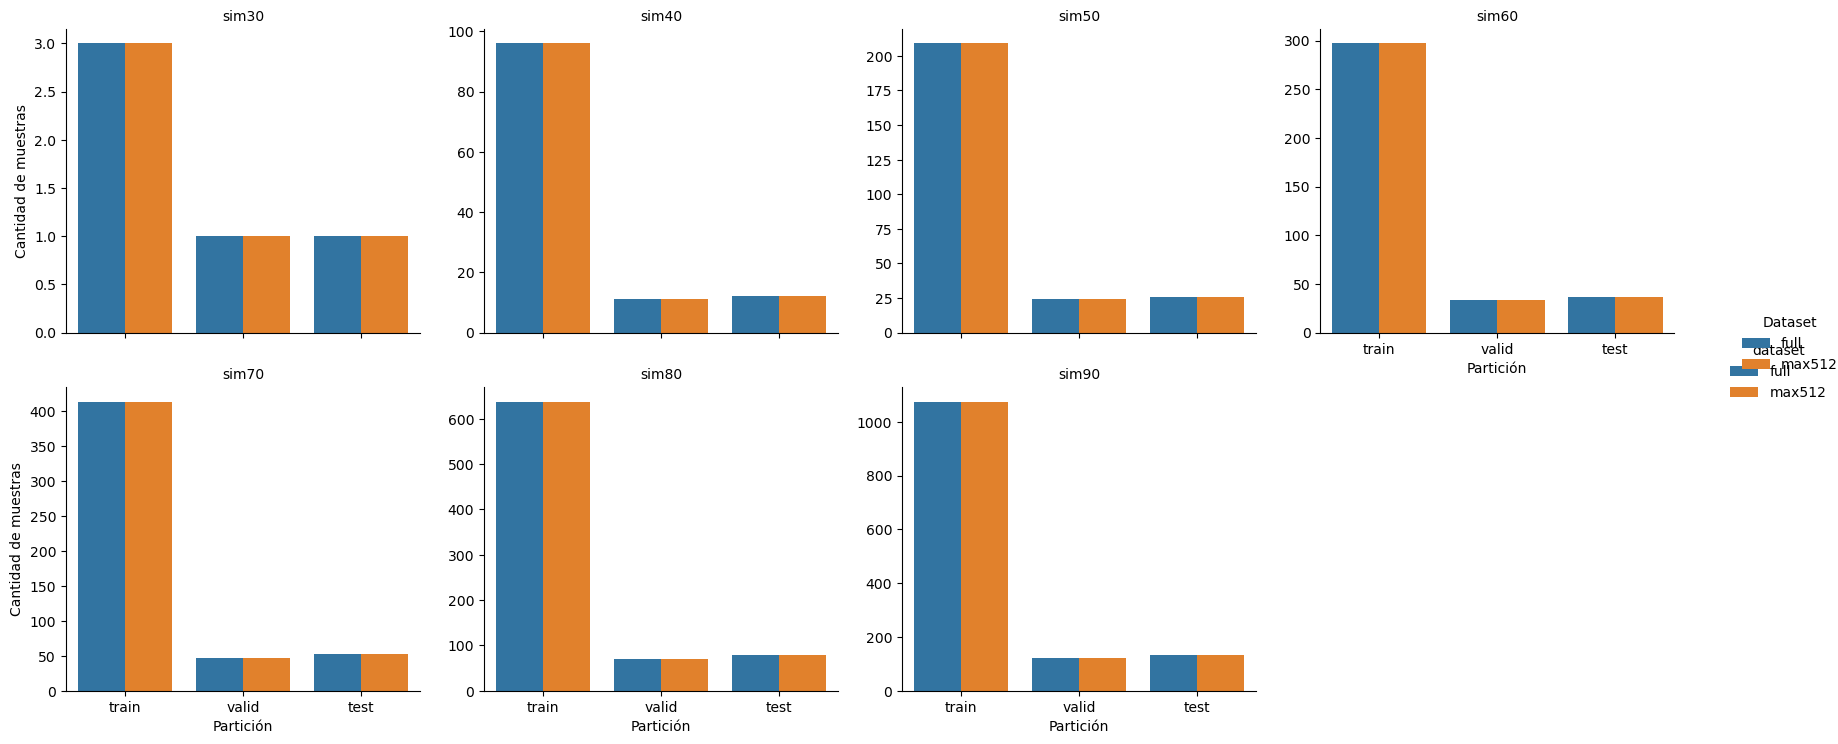

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=counts_df,
    kind="bar",
    x="partition",
    y="count",
    hue="dataset",
    col="sim",
    col_wrap=4,
    height=4,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Partición", "Cantidad de muestras")

g.fig.subplots_adjust(top=0.9, right=0.85)  
g.add_legend(title="Dataset")
g._legend.set_bbox_to_anchor((1.02, 0.5))   

plt.show()